# Deep Learning Workshop — Notebook 2 of 2
## CNNs, RNNs, Generative Models & a Taste of Deep RL

**Recap of the map:**

| Notebook | Covers |
|---|---|
| 1 | Foundations — neuron, MLPs from scratch, activations, losses, backprop, optimizers, PyTorch basics, 2 projects |
| **2 (this one)** | **CNNs & architectures, RNN/LSTM/GRU, Autoencoders & GANs, Deep RL intro, 2 more hands-on projects** |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

print("Torch:", torch.__version__)
print("Setup complete ✅")

Torch: 2.11.0+cpu
Setup complete ✅


---
# Part A — Convolutional Neural Networks: the mechanics

MLPs treat every pixel as an independent feature and ignore spatial structure. **CNNs** exploit the fact that nearby pixels are correlated, using three key ideas:

1. **Convolution** — slide a small learnable filter (kernel) over the image to detect local patterns (edges, textures) — the same filter is reused across the whole image (**parameter sharing**).
2. **Pooling** — downsample feature maps (e.g. max-pooling) to shrink spatial size and add translation tolerance.
3. **Stacking** — early layers learn edges → mid layers learn shapes/textures → deep layers learn whole objects.

Let's implement convolution and max-pooling from scratch with NumPy before letting PyTorch do it.


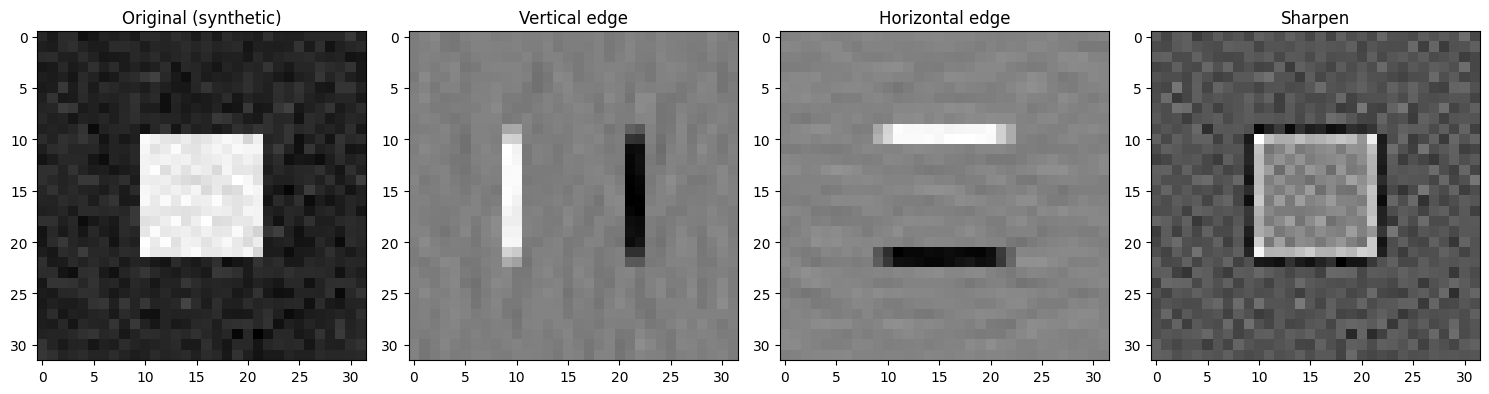

In [2]:
def conv2d_single(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)))
    ih, iw = image.shape
    kh, kw = kernel.shape
    oh = (ih - kh) // stride + 1
    ow = (iw - kw) // stride + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            region = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            out[i, j] = np.sum(region * kernel)
    return out

def max_pool2d(feat, size=2, stride=2):
    h, w = feat.shape
    oh = (h - size) // stride + 1
    ow = (w - size) // stride + 1
    out = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            region = feat[i*stride:i*stride+size, j*stride:j*stride+size]
            out[i, j] = region.max()
    return out

# A synthetic 32x32 image with a bright square in the middle
img = np.zeros((32, 32))
img[10:22, 10:22] = 1.0
img += rng.normal(0, 0.05, img.shape)

kernels = {
    'Vertical edge':   np.array([[-1,0,1],[-1,0,1],[-1,0,1]]),
    'Horizontal edge':  np.array([[-1,-1,-1],[0,0,0],[1,1,1]]),
    'Sharpen':          np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
}

fig, axes = plt.subplots(1, 4, figsize=(15,4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('Original (synthetic)')
for ax, (name, k) in zip(axes[1:], kernels.items()):
    out = conv2d_single(img, k, padding=1)
    ax.imshow(out, cmap='gray')
    ax.set_title(name)
plt.tight_layout(); plt.show()

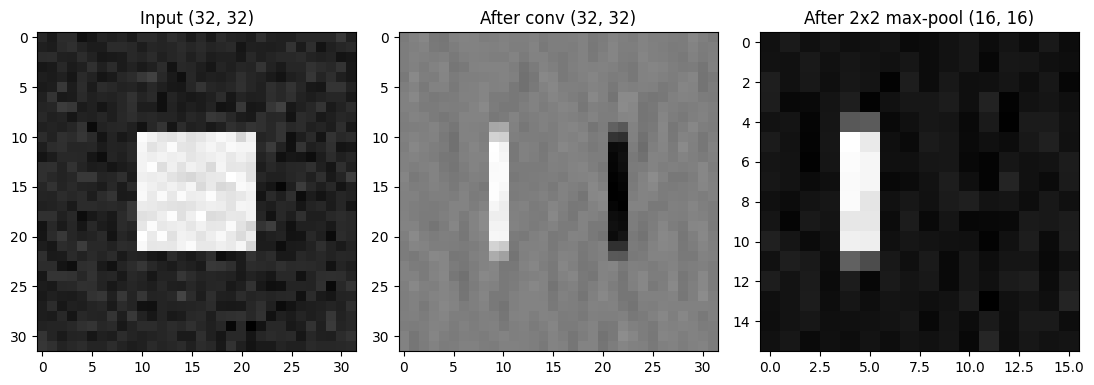

Pooling shrinks the spatial size while keeping the strongest activations —
this is why deep CNNs can go deeper without exploding in size.


In [3]:
# Convolution + pooling pipeline
feat = conv2d_single(img, kernels['Vertical edge'], padding=1)
pooled = max_pool2d(feat, size=2, stride=2)

fig, axes = plt.subplots(1, 3, figsize=(11,4))
axes[0].imshow(img, cmap='gray'); axes[0].set_title(f'Input {img.shape}')
axes[1].imshow(feat, cmap='gray'); axes[1].set_title(f'After conv {feat.shape}')
axes[2].imshow(pooled, cmap='gray'); axes[2].set_title(f'After 2x2 max-pool {pooled.shape}')
plt.tight_layout(); plt.show()
print("Pooling shrinks the spatial size while keeping the strongest activations —")
print("this is why deep CNNs can go deeper without exploding in size.")

## A.1 Classic CNN Architectures (concepts)

| Architecture | Key idea | Year |
|---|---|---|
| **LeNet-5** | First practical CNN — conv+pool stacks for digit recognition | 1998 |
| **AlexNet** | Deeper + ReLU + Dropout + GPU training, won ImageNet 2012 | 2012 |
| **VGG** | Very deep, uniform 3x3 convolutions stacked | 2014 |
| **GoogLeNet / Inception** | Parallel filters of different sizes in each block ("Inception module") | 2014 |
| **ResNet** | **Residual/skip connections** let gradients flow through 50–150+ layers | 2015 |

**Why ResNet mattered:** beyond a certain depth, plain CNNs got *worse* with more layers (degradation problem, tied to vanishing gradients). Residual connections `output = F(x) + x` let a layer easily learn "do nothing" (identity), making very deep networks trainable.


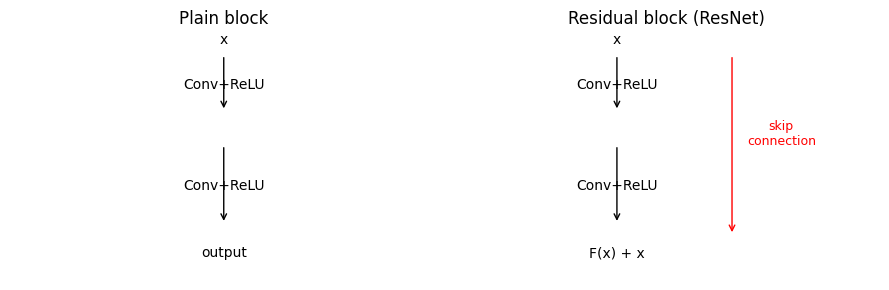

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9,3))

# Plain block
ax = axes[0]
ax.axis('off'); ax.set_title('Plain block')
ax.annotate('', xy=(0.5,0.75), xytext=(0.5,1.0), arrowprops=dict(arrowstyle='->'))
ax.text(0.5,0.85,'Conv+ReLU', ha='center')
ax.annotate('', xy=(0.5,0.25), xytext=(0.5,0.6), arrowprops=dict(arrowstyle='->'))
ax.text(0.5,0.4,'Conv+ReLU', ha='center')
ax.text(0.5,1.05,'x', ha='center'); ax.text(0.5,0.1,'output', ha='center')
ax.set_xlim(0,1); ax.set_ylim(0,1.1)

# Residual block
ax = axes[1]
ax.axis('off'); ax.set_title('Residual block (ResNet)')
ax.annotate('', xy=(0.5,0.75), xytext=(0.5,1.0), arrowprops=dict(arrowstyle='->'))
ax.text(0.5,0.85,'Conv+ReLU', ha='center')
ax.annotate('', xy=(0.5,0.25), xytext=(0.5,0.6), arrowprops=dict(arrowstyle='->'))
ax.text(0.5,0.4,'Conv+ReLU', ha='center')
ax.annotate('', xy=(0.85,0.2), xytext=(0.85,1.0), arrowprops=dict(arrowstyle='->', color='red'))
ax.text(1.0,0.6,'skip\nconnection', ha='center', color='red', fontsize=9)
ax.text(0.5,1.05,'x', ha='center'); ax.text(0.5,0.1,'F(x) + x', ha='center')
ax.set_xlim(0,1.3); ax.set_ylim(0,1.1)

plt.tight_layout(); plt.show()

---
# 🛠️ Project 1 — Shape Image Classifier (CNN)

image-classification style projects (e.g. *"Image classification using CIFAR-10"*), but instead of downloading a real dataset we **procedurally draw** thousands of images of circles, squares, and triangles with `PIL`, with randomized position, size, and pixel noise — then train a CNN to classify the shape.

**Pipeline:** synthetic image generation → dataset/dataloader → CNN in PyTorch → training → evaluation → feature-map visualization.


Image dataset shape: (900, 32, 32)


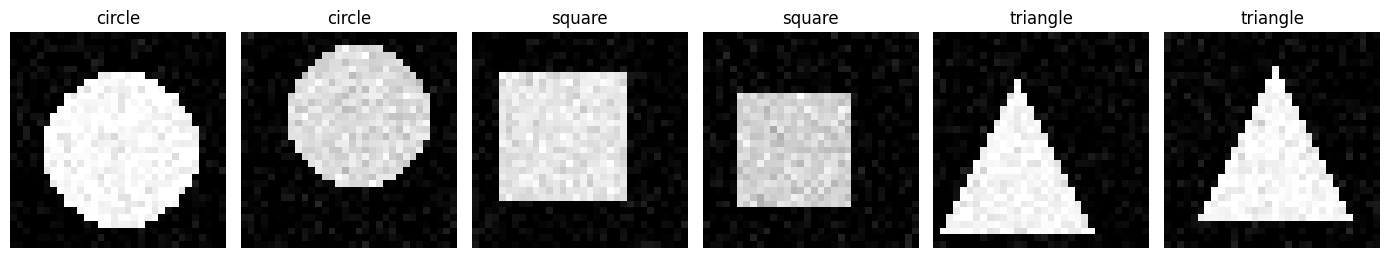

In [5]:
def make_shape_image(shape, size=32, rng=None):
    rng = rng or np.random.default_rng()
    img = Image.new('L', (size, size), color=0)
    draw = ImageDraw.Draw(img)
    cx = size // 2 + int(rng.integers(-4, 4))
    cy = size // 2 + int(rng.integers(-4, 4))
    r = int(rng.integers(8, 13))
    fill = int(rng.integers(180, 255))
    if shape == 'circle':
        draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=fill)
    elif shape == 'square':
        draw.rectangle([cx-r, cy-r, cx+r, cy+r], fill=fill)
    elif shape == 'triangle':
        draw.polygon([(cx, cy-r), (cx-r, cy+r), (cx+r, cy+r)], fill=fill)
    arr = np.array(img, dtype=np.float32) / 255.0
    noise = rng.normal(0, 0.05, size=arr.shape)
    return np.clip(arr + noise, 0, 1)

shape_names = ['circle', 'square', 'triangle']
n_per_class = 300
X_img, y_img = [], []
for label, shape in enumerate(shape_names):
    for _ in range(n_per_class):
        X_img.append(make_shape_image(shape, rng=rng))
        y_img.append(label)
X_img = np.array(X_img, dtype=np.float32)
y_img = np.array(y_img)
print("Image dataset shape:", X_img.shape)

fig, axes = plt.subplots(1, 6, figsize=(14,3))
for ax, idx in zip(axes, [0, 1, n_per_class, n_per_class+1, 2*n_per_class, 2*n_per_class+1]):
    ax.imshow(X_img[idx], cmap='gray'); ax.set_title(shape_names[y_img[idx]]); ax.axis('off')
plt.tight_layout(); plt.show()

epoch 1/8 | loss 0.9554
epoch 2/8 | loss 0.4948
epoch 3/8 | loss 0.2910
epoch 4/8 | loss 0.1465
epoch 5/8 | loss 0.0808
epoch 6/8 | loss 0.0552
epoch 7/8 | loss 0.0235
epoch 8/8 | loss 0.0200


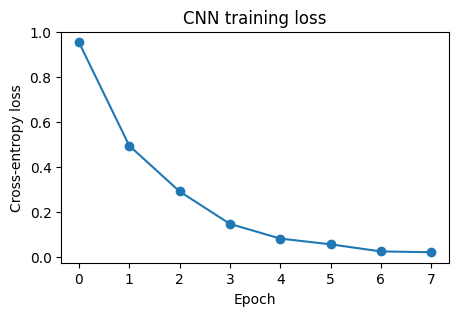

In [6]:
# --- Train/test split & PyTorch Dataset ---
Xtr, Xte, ytr, yte = train_test_split(X_img, y_img, test_size=0.2, stratify=y_img, random_state=RANDOM_STATE)

class ShapeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # add channel dim -> (N,1,H,W)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(ShapeDataset(Xtr, ytr), batch_size=32, shuffle=True)
test_loader  = DataLoader(ShapeDataset(Xte, yte), batch_size=64, shuffle=False)

class ShapeCNN(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # 32x32 -> 32x32
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # 16x16 -> 16x16
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # -> (B,8,16,16)
        x = self.pool(self.relu(self.conv2(x)))   # -> (B,16,8,8)
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

cnn = ShapeCNN(n_classes=3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

n_epochs = 8
train_losses = []
for epoch in range(n_epochs):
    cnn.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = cnn(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"epoch {epoch+1}/{n_epochs} | loss {epoch_loss:.4f}")

plt.figure(figsize=(5,3))
plt.plot(train_losses, marker='o'); plt.title('CNN training loss')
plt.xlabel('Epoch'); plt.ylabel('Cross-entropy loss'); plt.show()

Test accuracy: 1.000



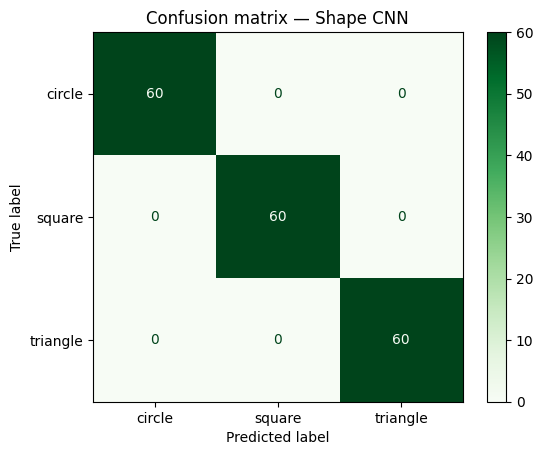

In [7]:
# --- Evaluate ---
cnn.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = cnn(xb).argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_true.extend(yb.numpy())

acc = accuracy_score(all_true, all_preds)
print(f"Test accuracy: {acc:.3f}\n")

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=shape_names)
disp.plot(cmap='Greens')
plt.title('Confusion matrix — Shape CNN')
plt.show()

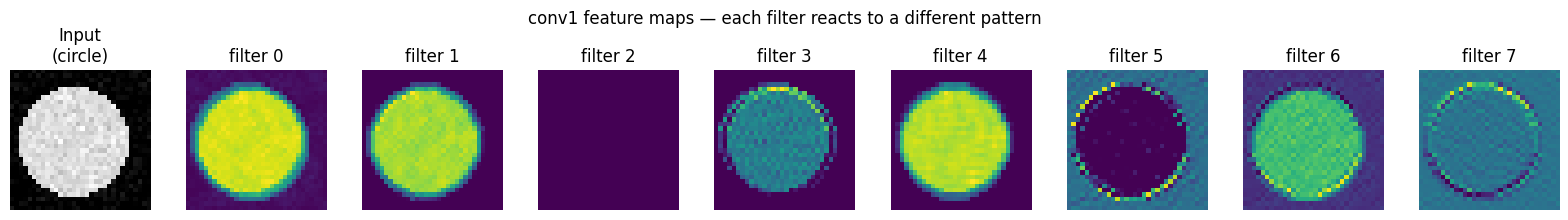

In [8]:
# --- Visualize learned feature maps (what the CNN "sees") ---
sample_x, sample_y = ShapeDataset(Xte, yte)[0]
cnn.eval()
with torch.no_grad():
    fmap1 = cnn.relu(cnn.conv1(sample_x.unsqueeze(0)))[0]  # (8,32,32)

fig, axes = plt.subplots(1, 9, figsize=(16,2.2))
axes[0].imshow(sample_x[0], cmap='gray'); axes[0].set_title(f'Input\n({shape_names[sample_y.item()]})'); axes[0].axis('off')
for i in range(8):
    axes[i+1].imshow(fmap1[i], cmap='viridis'); axes[i+1].set_title(f'filter {i}'); axes[i+1].axis('off')
plt.suptitle('conv1 feature maps — each filter reacts to a different pattern')
plt.tight_layout(); plt.show()

---
# Part B — Recurrent Neural Networks

CNNs assume spatial locality; **sequence data** (text, time series, audio) instead has *temporal* structure — order matters and context accumulates over time. An RNN processes a sequence one step at a time, maintaining a **hidden state** that summarizes everything seen so far:

$$h_t = \phi(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$

### The vanishing/exploding gradient problem
Backprop through time multiplies gradients across every timestep. For long sequences, repeated multiplication by the same weight matrix can shrink gradients to ~0 (vanishing) or blow them up (exploding), making vanilla RNNs bad at learning long-range dependencies.

### LSTM & GRU
Both add **gating mechanisms** (learned "valves" controlling what to remember/forget/output) that let gradients flow over many more timesteps:
- **LSTM** — separate cell state + input/forget/output gates.
- **GRU** — simplified, 2 gates (update/reset), fewer parameters, often similar performance.


Hidden state after each timestep:
  t=0: [0. 0. 0. 0.]
  t=1: [0.414 0.1   0.24  0.508]
  t=2: [0.464 0.385 0.337 0.228]
  t=3: [ 0.123  0.183  0.164 -0.074]
  t=4: [0.672 0.148 0.441 0.772]
  t=5: [ 0.175  0.438  0.195 -0.419]


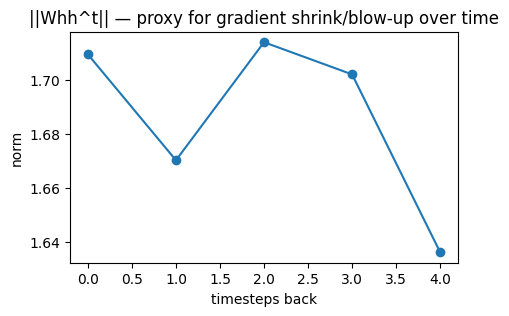

If this norm shrinks toward 0 -> vanishing gradients (forgets distant past).
If it grows unbounded -> exploding gradients (unstable training).
This is exactly the failure mode LSTM/GRU gates are designed to fix.


In [9]:
# Vanilla RNN cell from scratch — demonstrating the recurrence + vanishing gradient intuition
def rnn_step(x_t, h_prev, Wxh, Whh, bh):
    return np.tanh(Wxh @ x_t + Whh @ h_prev + bh)

np.random.seed(0)
hidden_dim, input_dim = 4, 1
Wxh = np.random.randn(hidden_dim, input_dim) * 0.5
Whh = np.random.randn(hidden_dim, hidden_dim) * 0.5
bh = np.zeros(hidden_dim)

seq = np.array([[0.5],[0.1],[-0.3],[0.8],[-0.6]])
h = np.zeros(hidden_dim)
grad_norms = []
h_states = [h.copy()]
for x_t in seq:
    h = rnn_step(x_t, h, Wxh, Whh, bh)
    h_states.append(h.copy())
    # crude proxy for how much influence h0 still has (spectral radius^t)
    grad_norms.append(np.linalg.norm(np.linalg.matrix_power(Whh, len(h_states)-1)))

print("Hidden state after each timestep:")
for t, h_t in enumerate(h_states):
    print(f"  t={t}: {np.round(h_t,3)}")

plt.figure(figsize=(5,3))
plt.plot(grad_norms, marker='o')
plt.title('||Whh^t|| — proxy for gradient shrink/blow-up over time')
plt.xlabel('timesteps back'); plt.ylabel('norm')
plt.show()
print("If this norm shrinks toward 0 -> vanishing gradients (forgets distant past).")
print("If it grows unbounded -> exploding gradients (unstable training).")
print("This is exactly the failure mode LSTM/GRU gates are designed to fix.")

---
# 🛠️ Project 2 — Sentiment Classifier (Embedding + LSTM)
*"Sentiment Analysis using Deep Learning"*-style projects. We procedurally generate short sentences built from positive/negative "signal" words mixed with neutral filler words in randomized order — the model must learn to detect the *presence* of a sentiment-carrying word regardless of its position, which is exactly the kind of long-range/positional robustness LSTMs are good at.

**Pipeline:** synthetic sentence generation → tokenization/vocab → padded sequences → Embedding+LSTM classifier → training → evaluation → prediction on a new sentence.


In [10]:
positive_words = ['great','amazing','wonderful','fantastic','love','excellent','happy','best','brilliant','superb']
negative_words = ['terrible','awful','horrible','bad','hate','worst','disappointing','poor','boring','sad']
neutral_fillers = ['the','movie','food','service','product','experience','this','is','really','quite','so','very','it','that','honestly','overall']

def gen_sentence(label, rng, max_len=8):
    sent_word = rng.choice(positive_words if label == 1 else negative_words)
    n_extra = rng.integers(3, 6)
    words = ['the', str(rng.choice(neutral_fillers)), 'was', sent_word] + list(rng.choice(neutral_fillers, size=n_extra))
    rng.shuffle(words)
    return words[:max_len]

n_samples = 1200
sentences, labels = [], []
for _ in range(n_samples):
    label = int(rng.integers(0, 2))
    sentences.append(gen_sentence(label, rng))
    labels.append(label)

vocab = sorted(set(w for s in sentences for w in s))
word2idx = {w: i + 1 for i, w in enumerate(vocab)}  # index 0 reserved for padding
vocab_size = len(vocab) + 1
max_len = max(len(s) for s in sentences)

def encode(sentence):
    ids = [word2idx[w] for w in sentence]
    return ids + [0] * (max_len - len(ids))

X_text = np.array([encode(s) for s in sentences])
y_text = np.array(labels)

print("Vocab size:", vocab_size, "| Max sentence length:", max_len)
print("Example:", ' '.join(sentences[0]), "-> label:", "positive" if labels[0]==1 else "negative")
print("Encoded:", X_text[0])

Vocab size: 38 | Max sentence length: 8
Example: superb movie the the was honestly this -> label: positive
Encoded: [29 20 32 32 35 15 33  0]


epoch 1/10 | loss 0.6832
epoch 2/10 | loss 0.4870
epoch 3/10 | loss 0.1339
epoch 4/10 | loss 0.0649
epoch 5/10 | loss 0.0364
epoch 6/10 | loss 0.0266
epoch 7/10 | loss 0.0209
epoch 8/10 | loss 0.0109
epoch 9/10 | loss 0.0105
epoch 10/10 | loss 0.0120


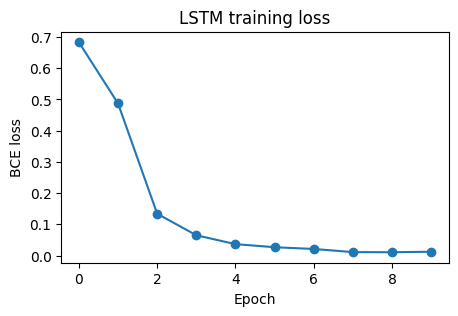

In [11]:
# --- Train/test split & PyTorch Dataset ---
Xtr, Xte, ytr, yte = train_test_split(X_text, y_text, test_size=0.2, stratify=y_text, random_state=RANDOM_STATE)

class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(SentimentDataset(Xtr, ytr), batch_size=32, shuffle=True)
test_loader  = DataLoader(SentimentDataset(Xte, yte), batch_size=64, shuffle=False)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=16, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb = self.embedding(x)                 # (B, T, embed_dim)
        _, (h_n, _) = self.lstm(emb)             # h_n: (1, B, hidden_dim)
        return self.fc(h_n.squeeze(0))           # (B, 1) logits

lstm_model = LSTMClassifier(vocab_size)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.005)

n_epochs = 10
train_losses = []
for epoch in range(n_epochs):
    lstm_model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = lstm_model(xb).squeeze(1)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"epoch {epoch+1}/{n_epochs} | loss {epoch_loss:.4f}")

plt.figure(figsize=(5,3))
plt.plot(train_losses, marker='o'); plt.title('LSTM training loss')
plt.xlabel('Epoch'); plt.ylabel('BCE loss'); plt.show()

Test accuracy: 0.971


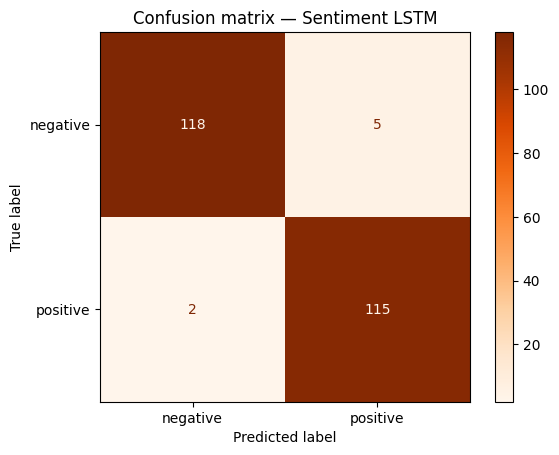

In [12]:
# --- Evaluate ---
lstm_model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = (torch.sigmoid(lstm_model(xb).squeeze(1)) > 0.5).float()
        all_preds.extend(preds.numpy())
        all_true.extend(yb.numpy())

acc = accuracy_score(all_true, all_preds)
print(f"Test accuracy: {acc:.3f}")

cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative','positive'])
disp.plot(cmap='Oranges')
plt.title('Confusion matrix — Sentiment LSTM')
plt.show()

In [13]:
# --- Try it on a brand new sentence ---
def predict_sentiment(sentence_words):
    unknown = [w for w in sentence_words if w not in word2idx]
    ids = [word2idx.get(w, 0) for w in sentence_words][:max_len]
    ids = ids + [0] * (max_len - len(ids))
    x = torch.tensor([ids], dtype=torch.long)
    lstm_model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(lstm_model(x)).item()
    label = 'positive' if prob > 0.5 else 'negative'
    print(f"'{' '.join(sentence_words)}' -> {label} ({prob*100:.1f}% positive)")
    if unknown:
        print(f"  (note: {unknown} not seen during training, treated as padding)")

predict_sentiment(['this', 'product', 'is', 'fantastic', 'so', 'good'])
predict_sentiment(['the', 'service', 'was', 'terrible', 'quite', 'boring'])

'this product is fantastic so good' -> positive (100.0% positive)
  (note: ['good'] not seen during training, treated as padding)
'the service was terrible quite boring' -> negative (0.0% positive)


---
# Part C — Generative Models: Autoencoders & GANs

Everything so far was **discriminative**: learn $P(y|x)$ to predict a label. **Generative models** instead learn to produce *new* data resembling the training distribution.

## C.1 Autoencoder
An autoencoder compresses input into a low-dimensional **latent code** (encoder) and reconstructs the original from it (decoder), trained to minimize reconstruction error. The bottleneck forces it to learn a compact, meaningful representation. Used for denoising, dimensionality reduction, and anomaly detection.


epoch 1/10 | reconstruction MSE 0.22425
epoch 2/10 | reconstruction MSE 0.19677
epoch 3/10 | reconstruction MSE 0.11477
epoch 4/10 | reconstruction MSE 0.06048
epoch 5/10 | reconstruction MSE 0.04213
epoch 6/10 | reconstruction MSE 0.03379
epoch 7/10 | reconstruction MSE 0.02864
epoch 8/10 | reconstruction MSE 0.02510
epoch 9/10 | reconstruction MSE 0.02258
epoch 10/10 | reconstruction MSE 0.02072


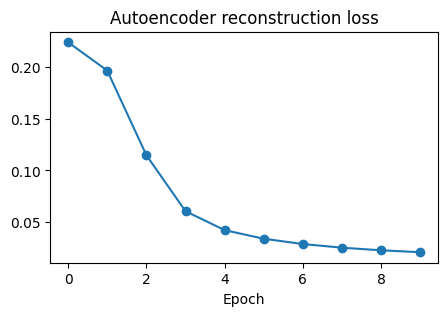

In [14]:
# Convolutional autoencoder on our synthetic shape images
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),   # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),  # 16x16 -> 8x8
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1),   # 16x16 -> 32x32
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

ae = ConvAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(ae.parameters(), lr=0.001)

ae_loader = DataLoader(ShapeDataset(X_img, y_img), batch_size=32, shuffle=True)

ae_losses = []
for epoch in range(10):
    ae.train()
    epoch_loss = 0
    for xb, _ in ae_loader:
        optimizer.zero_grad()
        recon, _ = ae(xb)
        loss = criterion(recon, xb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(ae_loader.dataset)
    ae_losses.append(epoch_loss)
    print(f"epoch {epoch+1}/10 | reconstruction MSE {epoch_loss:.5f}")

plt.figure(figsize=(5,3)); plt.plot(ae_losses, marker='o')
plt.title('Autoencoder reconstruction loss'); plt.xlabel('Epoch'); plt.show()

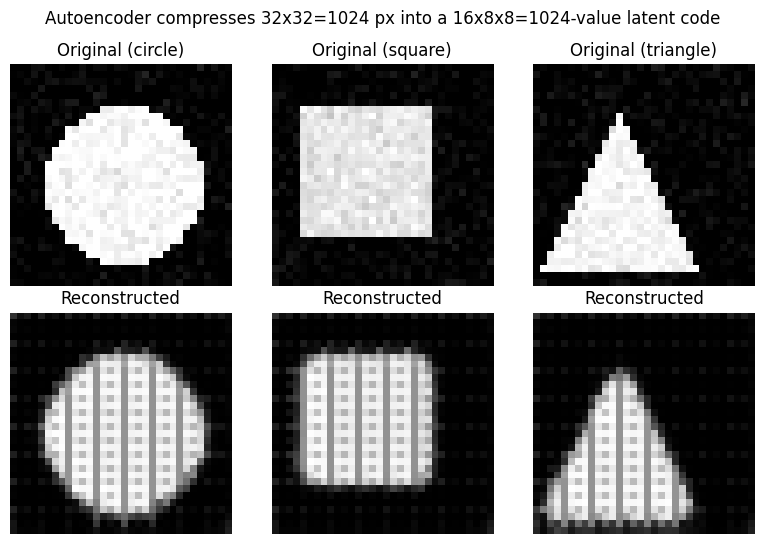

In [15]:
# Visualize original vs reconstructed
ae.eval()
sample_batch = torch.tensor(X_img[[0, n_per_class, 2*n_per_class]], dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    recon, latent = ae(sample_batch)

fig, axes = plt.subplots(2, 3, figsize=(8,5.5))
for i in range(3):
    axes[0,i].imshow(sample_batch[i,0], cmap='gray'); axes[0,i].set_title(f'Original ({shape_names[i]})'); axes[0,i].axis('off')
    axes[1,i].imshow(recon[i,0], cmap='gray'); axes[1,i].set_title('Reconstructed'); axes[1,i].axis('off')
plt.suptitle(f'Autoencoder compresses 32x32=1024 px into a {latent.shape[1]}x{latent.shape[2]}x{latent.shape[3]}={latent[0].numel()}-value latent code')
plt.tight_layout(); plt.show()

## C.2 Generative Adversarial Networks (GANs)

A GAN pits two networks against each other:
- **Generator (G)** — takes random noise and tries to produce fake samples that look real.
- **Discriminator (D)** — tries to tell real samples from G's fakes.

They're trained jointly: D gets better at spotting fakes, which forces G to get better at fooling it. At equilibrium, G's output distribution matches the real data distribution.

To keep training fast and the dynamics easy to visualize live in a workshop, we train a small GAN on a **2D synthetic distribution** (two interleaving moons) rather than images — you'll clearly see the generated point cloud converge onto the real one.


In [16]:
# Real distribution
X_real, _ = make_moons(n_samples=1000, noise=0.08, random_state=RANDOM_STATE)
X_real = StandardScaler().fit_transform(X_real).astype(np.float32)
X_real_t = torch.tensor(X_real)

noise_dim = 8

class Generator(nn.Module):
    def __init__(self, noise_dim, out_dim=2, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim=2, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden), nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1)
        )
    def forward(self, x): return self.net(x)

G = Generator(noise_dim)
D = Discriminator()
criterion = nn.BCEWithLogitsLoss()
opt_G = optim.Adam(G.parameters(), lr=0.001, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.001, betas=(0.5, 0.999))

batch_size = 128
n_iters = 3000
snapshots = {}
snapshot_points = [0, 500, 1500, 2999]

for it in range(n_iters):
    # --- train Discriminator ---
    idx = np.random.randint(0, X_real_t.shape[0], batch_size)
    real_batch = X_real_t[idx]
    z = torch.randn(batch_size, noise_dim)
    fake_batch = G(z).detach()

    opt_D.zero_grad()
    real_labels = torch.ones(batch_size, 1) * 0.9   # label smoothing
    fake_labels = torch.zeros(batch_size, 1)
    d_loss = criterion(D(real_batch), real_labels) + criterion(D(fake_batch), fake_labels)
    d_loss.backward()
    opt_D.step()

    # --- train Generator ---
    z = torch.randn(batch_size, noise_dim)
    fake_batch = G(z)
    opt_G.zero_grad()
    g_loss = criterion(D(fake_batch), torch.ones(batch_size, 1))   # wants D to say "real"
    g_loss.backward()
    opt_G.step()

    if it in snapshot_points:
        with torch.no_grad():
            z_vis = torch.randn(500, noise_dim)
            snapshots[it] = G(z_vis).numpy()
        print(f"iter {it:4d} | D loss {d_loss.item():.3f} | G loss {g_loss.item():.3f}")

iter    0 | D loss 1.391 | G loss 0.654
iter  500 | D loss 1.379 | G loss 0.752
iter 1500 | D loss 1.344 | G loss 0.828
iter 2999 | D loss 1.375 | G loss 0.807


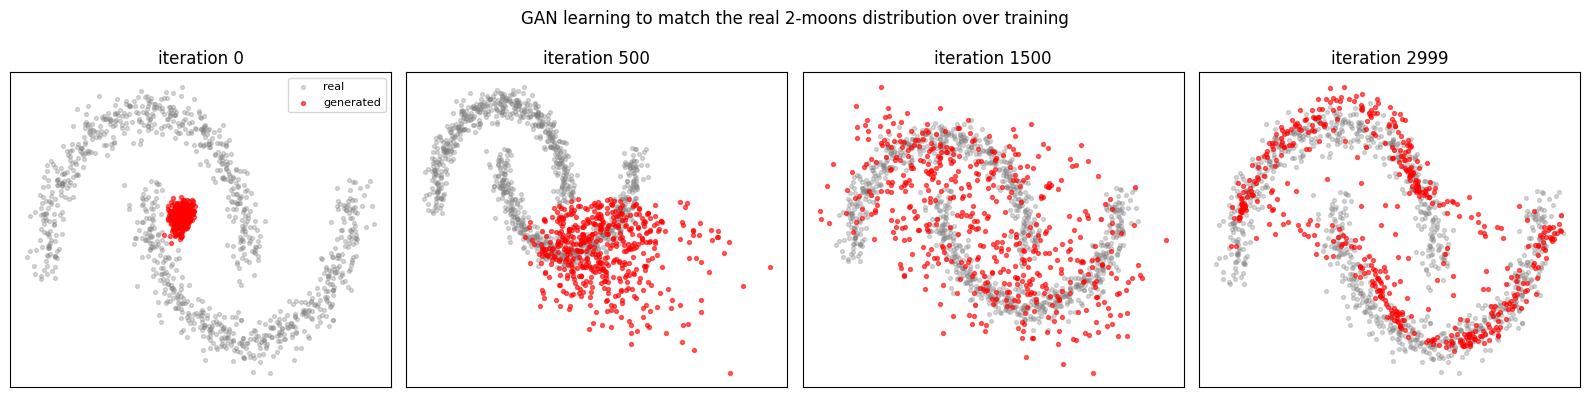

In [17]:
fig, axes = plt.subplots(1, len(snapshot_points), figsize=(16,4))
for ax, it in zip(axes, snapshot_points):
    ax.scatter(X_real[:,0], X_real[:,1], s=8, alpha=0.3, label='real', color='gray')
    ax.scatter(snapshots[it][:,0], snapshots[it][:,1], s=8, alpha=0.6, label='generated', color='red')
    ax.set_title(f'iteration {it}')
    ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc='upper right', fontsize=8)
plt.suptitle('GAN learning to match the real 2-moons distribution over training')
plt.tight_layout(); plt.show()

**What to point out live:** early on, G's points look like a random blob (it starts from noise). As training progresses, the red point cloud gradually reshapes itself to cover the same two crescent moons as the gray real data — G never sees the real data directly, it only learns from D's feedback.


---
# Part D — A Taste of Deep Reinforcement Learning

Reinforcement Learning (RL) is a different paradigm: an **agent** interacts with an **environment**, taking **actions**, receiving **rewards**, and learning a **policy** that maximizes cumulative reward — with no labeled dataset at all, just trial and error.

- **State** — the agent's current situation.
- **Action** — a choice the agent can make.
- **Reward** — feedback signal after each action.
- **Q-value** $Q(s,a)$ — expected future reward of taking action $a$ in state $s$, then acting optimally afterward.
- **Deep Q-Networks (DQN)** — when states are too large/continuous for a lookup table, a neural network approximates $Q(s,a)$ instead. The core update rule is the same.

We'll implement **tabular Q-learning** (the non-deep foundation DQN builds on) on a small custom grid-world — small enough to solve exactly, so you can see the update rule directly:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \big[r + \gamma \max_{a'} Q(s', a') - Q(s,a)\big]$$


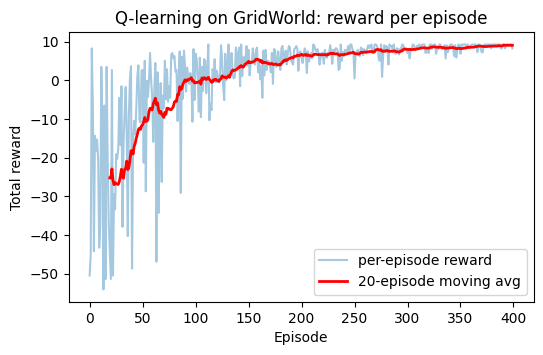

Avg reward first 20 episodes: -25.25
Avg reward last 20 episodes:  9.09


In [18]:
class GridWorld:
    """5x5 grid. Agent starts top-left, goal bottom-right, some obstacles."""
    def __init__(self, size=5, goal=(4, 4), obstacles=((1, 1), (2, 2), (3, 1))):
        self.size = size
        self.goal = goal
        self.obstacles = set(obstacles)
        self.n_states = size * size
        self.n_actions = 4  # up, down, left, right
        self.actions = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

    def state_to_idx(self, s):
        return s[0] * self.size + s[1]

    def reset(self):
        self.state = (0, 0)
        return self.state_to_idx(self.state)

    def step(self, a):
        dr, dc = self.actions[a]
        r, c = self.state
        nr, nc = r + dr, c + dc
        if not (0 <= nr < self.size and 0 <= nc < self.size) or (nr, nc) in self.obstacles:
            nr, nc = r, c
            reward = -1.0
        elif (nr, nc) == self.goal:
            reward = 10.0
        else:
            reward = -0.1
        self.state = (nr, nc)
        done = self.state == self.goal
        return self.state_to_idx(self.state), reward, done

env = GridWorld()
Q = np.zeros((env.n_states, env.n_actions))
alpha, gamma = 0.5, 0.95
epsilon_start, epsilon_end, n_episodes = 1.0, 0.05, 400
reward_history = []

for ep in range(n_episodes):
    epsilon = epsilon_start - (epsilon_start - epsilon_end) * (ep / n_episodes)
    s = env.reset()
    total_reward = 0
    for t in range(100):
        if rng.random() < epsilon:
            a = rng.integers(env.n_actions)
        else:
            a = int(np.argmax(Q[s]))
        s2, r, done = env.step(a)
        Q[s, a] += alpha * (r + gamma * np.max(Q[s2]) - Q[s, a])
        s = s2
        total_reward += r
        if done:
            break
    reward_history.append(total_reward)

plt.figure(figsize=(6,3.5))
plt.plot(reward_history, alpha=0.4, label='per-episode reward')
window = 20
smoothed = np.convolve(reward_history, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, n_episodes), smoothed, color='red', lw=2, label=f'{window}-episode moving avg')
plt.title('Q-learning on GridWorld: reward per episode')
plt.xlabel('Episode'); plt.ylabel('Total reward'); plt.legend(); plt.show()
print(f"Avg reward first 20 episodes: {np.mean(reward_history[:20]):.2f}")
print(f"Avg reward last 20 episodes:  {np.mean(reward_history[-20:]):.2f}")

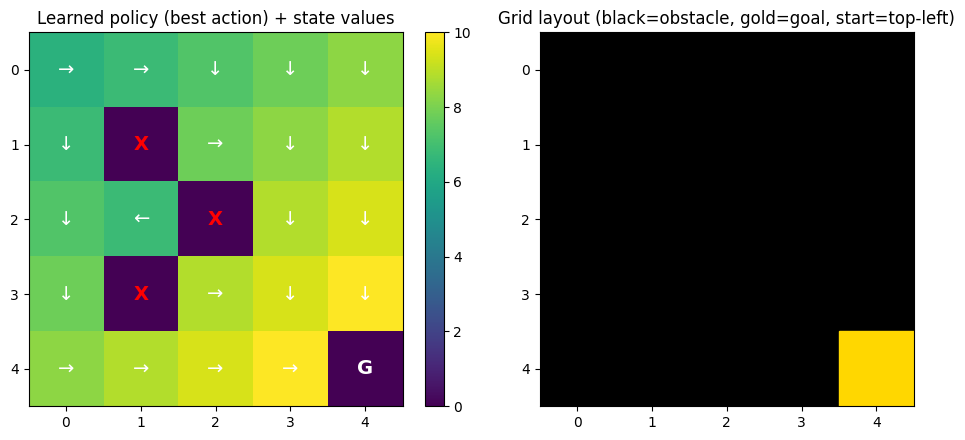

In [19]:
# Visualize the learned policy (best action per cell) and state values
policy = np.argmax(Q, axis=1).reshape(env.size, env.size)
values = np.max(Q, axis=1).reshape(env.size, env.size)
arrow_map = {0: '↑', 1: '↓', 2: '←', 3: '→'}

fig, axes = plt.subplots(1, 2, figsize=(10,4.5))

im = axes[0].imshow(values, cmap='viridis')
for r in range(env.size):
    for c in range(env.size):
        if (r, c) in env.obstacles:
            axes[0].text(c, r, 'X', ha='center', va='center', color='red', fontsize=14, fontweight='bold')
        elif (r, c) == env.goal:
            axes[0].text(c, r, 'G', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
        else:
            axes[0].text(c, r, arrow_map[policy[r, c]], ha='center', va='center', color='white', fontsize=14)
axes[0].set_title('Learned policy (best action) + state values')
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow(np.zeros((env.size, env.size)), cmap='gray', vmin=0, vmax=1)
for r in range(env.size):
    for c in range(env.size):
        if (r, c) in env.obstacles:
            axes[1].add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='black'))
        elif (r, c) == env.goal:
            axes[1].add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='gold'))
axes[1].set_title('Grid layout (black=obstacle, gold=goal, start=top-left)')
axes[1].set_xticks(range(env.size)); axes[1].set_yticks(range(env.size))
plt.tight_layout(); plt.show()

**From tabular Q-learning to Deep Q-Networks (DQN):** here `Q` was just a 25x4 table because the grid is tiny. For environments like Atari or robotics, the state space is enormous or continuous (e.g. raw pixels), so a table is impossible — DQN replaces the table with a neural network `Q(s,a; θ)` trained with the exact same TD-error signal, plus two key stabilization tricks: **experience replay** (train on a buffer of past transitions, not just the latest one) and a **target network** (a slowly-updated copy of the Q-network for stable targets). Everything else — the Bellman update, epsilon-greedy exploration — carries over directly from what you just watched converge above.


---
# ✅ Recap — What we covered in Notebook 2

- Convolution & pooling from scratch, and the intuition behind LeNet → AlexNet → VGG → ResNet
- **Project:** a CNN classifying synthetic shape images, with feature-map visualization
- Vanilla RNNs and *why* they struggle with long sequences (vanishing/exploding gradients), and how LSTM/GRU gates address it
- **Project:** an Embedding + LSTM sentiment classifier on synthetic sentences
- Autoencoders (compression + reconstruction) and GANs (generator vs discriminator), visualized live learning a 2D distribution
- Tabular Q-learning on a custom grid-world, and how it generalizes to Deep Q-Networks
